# 1. 준비하기: Pandas 라이브러리 설치
가장 먼저 우리가 사용할 마법의 도구인 `pandas`를 설치해야 해요.
아래 코드를 실행(Shift + Enter)해 주세요!

In [35]:
!pip install pandas matplotlib

Defaulting to user installation because normal site-packages is not writeable


# 2. 기후 데이터베이스 불러오기
설치가 끝났다면, 우리가 분석할 기후 데이터베이스에서 `기후_종합` 뷰(View)를 표 형태로 예쁘게 불러와 볼까요?

In [36]:
import sqlite3
import pandas as pd

# 1. 데이터베이스 파일과 연결하기
# 파일이 같은 폴더에 있으므로 이름만 적어주면 됩니다.
conn = sqlite3.connect('기후_데이터.db')

# 2. '기후_종합' 뷰에서 데이터를 전부 가져와서 df(데이터프레임)에 저장하기
query = "SELECT * FROM 기후_종합"
df = pd.read_sql(query, conn)

# 3. 데이터베이스 연결 종료하기 (다 가져왔으면 문을 닫아줍니다)
conn.close()

# 4. 불러온 데이터가 잘 들어왔는지 위에서부터 5줄만 확인해보기
df.head()

,날짜,강수량(mm),기온(℃),최저기온(℃),최고기온(℃)
0,1973-01-01,0.4,2.1,-1.3,5.9
1,1973-01-02,1.2,-3.2,-7.8,2.3
2,1973-01-03,0.8,-4.8,-9.7,0.1
3,1973-01-04,0.1,-1.3,-6,4
4,1973-01-05,0,0,-3.8,5.2


# 3. 날짜 쪼개기
데이터에 있는 '날짜' 칼럼을 '연도', '월', '일'로 나누고, 원래 있던 '날짜' 칼럼은 지워볼게요!

In [37]:
# '-'를 기준으로 날짜를 쪼개서 새로운 칼럼 만들기
df[['연도', '월', '일']] = df['날짜'].str.split('-', expand=True)

# 원래 있던 '날짜' 칼럼 지우기
df = df.drop('날짜', axis=1)

# 잘 쪼개졌는지 확인해보기
df.head()

,강수량(mm),기온(℃),최저기온(℃),최고기온(℃),연도,월,일
0,0.4,2.1,-1.3,5.9,1973,01,01
1,1.2,-3.2,-7.8,2.3,1973,01,02
2,0.8,-4.8,-9.7,0.1,1973,01,03
3,0.1,-1.3,-6,4,1973,01,04
4,0,0,-3.8,5.2,1973,01,05


# 4. 데이터 모양(타입) 확인하고 진짜 숫자로 바꾸기
우리가 눈으로 볼 때는 숫자 같아도, 컴퓨터는 글자로 생각할 때가 있어요.
각 칼럼이 진짜 숫자인지 확인해 보고, 아니라면 계산할 수 있는 숫자로 바꿔줄게요!

In [38]:
# 컴퓨터의 어려운 영어를 친숙한 한글로 바꿔서 보여주는 마법의 함수!
def 친절한_모양_알려주기(데이터):
    for 칼럼 in 데이터.columns:
        모양 = 데이터[칼럼].dtype
        if 모양 == "object":
            print(f"{칼럼}: 그냥 글자 📝")
        elif 모양 == "float64":
            print(f"{칼럼}: 소수점이 있는 숫자 🌡️")
        elif 모양 == "int64":
            print(f"{칼럼}: 딱 떨어지는 숫자 📅")

# 1. 바꾸기 전의 모습 확인하기
print("--- 바꾸기 전 ---")
친절한_모양_알려주기(df)

# 2. 기후 데이터들은 소수가 있는 숫자(float)로 바꾸기
df['강수량(mm)'] = df['강수량(mm)'].astype(float)
df['기온(℃)'] = df['기온(℃)'].astype(float)
df['최저기온(℃)'] = df['최저기온(℃)'].astype(float)
df['최고기온(℃)'] = df['최고기온(℃)'].astype(float)

# 3. 날짜 데이터들은 소수가 없는 숫자(int)로 바꾸기
df['연도'] = df['연도'].astype(int)
df['월'] = df['월'].astype(int)
df['일'] = df['일'].astype(int)

# 4. 잘 바뀌었는지 다시 한번 확인해볼까요?
print("\n--- 바꾼 후 ---")
친절한_모양_알려주기(df)


--- 바꾸기 전 ---
강수량(mm): 그냥 글자 📝
기온(℃): 그냥 글자 📝
최저기온(℃): 그냥 글자 📝
최고기온(℃): 그냥 글자 📝
연도: 그냥 글자 📝
월: 그냥 글자 📝
일: 그냥 글자 📝

--- 바꾼 후 ---
강수량(mm): 소수점이 있는 숫자 🌡️
기온(℃): 소수점이 있는 숫자 🌡️
최저기온(℃): 소수점이 있는 숫자 🌡️
최고기온(℃): 소수점이 있는 숫자 🌡️
연도: 딱 떨어지는 숫자 📅
월: 딱 떨어지는 숫자 📅
일: 딱 떨어지는 숫자 📅


# 5. 2025년 2월 기온과 강수량 같이 보기 (보조축 사용!)
이번에는 하나의 그래프에 기온과 강수량을 같이 그려볼게요.
기온은 왼쪽 기준선(주축)으로, 강수량은 오른쪽 기준선(보조축)으로 보면 단위가 달라도 훨씬 깔끔하게 비교할 수 있답니다!

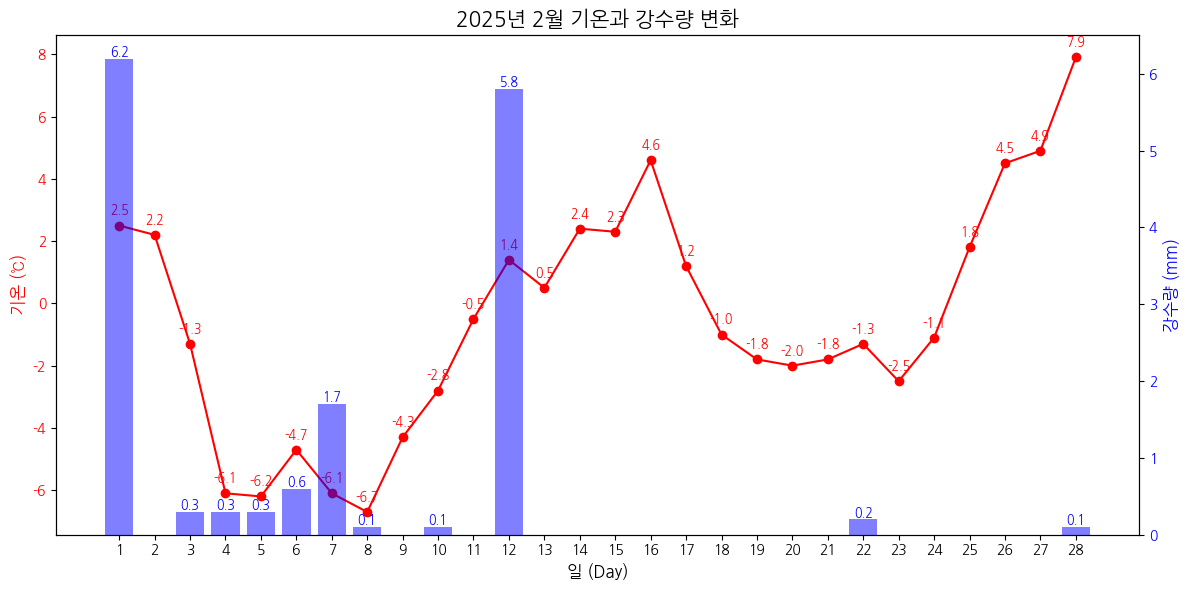

In [39]:
import matplotlib.pyplot as plt

# 1. 2025년 2월 데이터 쏙쏙 뽑기 (이제 숫자(int)로 바뀌었으니 2025, 2 라고 씁니다!)
condition = (df['연도'] == 2025) & (df['월'] == 2)
df_2025_02 = df[condition]

# 2. 그래프 그리기 준비!
fig, ax1 = plt.subplots(figsize=(12, 6))

# 3. 주축(왼쪽)에 기온 선 그래프 그리기 (빨간색 선)
ax1.plot(df_2025_02['일'], df_2025_02['기온(℃)'], color='red', marker='o', label='기온(℃)')
ax1.set_xlabel('일 (Day)', fontsize=12)
ax1.set_ylabel('기온 (℃)', color='red', fontsize=12)
ax1.tick_params(axis='y', labelcolor='red')

# x축(날짜) 눈금을 1일씩 전부 다 표시하기!
ax1.set_xticks(df_2025_02['일'])

# 기온 선 그래프 점 위에 숫자 값 적어주기
for i, txt in enumerate(df_2025_02['기온(℃)']):
    ax1.annotate(f'{txt}', (df_2025_02['일'].iloc[i], txt), textcoords="offset points", xytext=(0,8), ha='center', color='red', fontsize=9)

# 4. 보조축(오른쪽) 만들기 (왼쪽 그래프와 같은 x축을 공유해요!)
ax2 = ax1.twinx()

# 5. 보조축(오른쪽)에 강수량 막대 그래프 그리기 (파란색 막대)
ax2.bar(df_2025_02['일'], df_2025_02['강수량(mm)'], color='blue', alpha=0.5, label='강수량(mm)')
ax2.set_ylabel('강수량 (mm)', color='blue', fontsize=12)
ax2.tick_params(axis='y', labelcolor='blue')

# 강수량 막대 그래프 위에 숫자 값 적어주기 (비가 안 온 날 0.0은 빼고 적어요!)
for i, txt in enumerate(df_2025_02['강수량(mm)']):
    if txt > 0:
        ax2.annotate(f'{txt}', (df_2025_02['일'].iloc[i], txt), textcoords="offset points", xytext=(0,2), ha='center', color='blue', fontsize=9)

# 6. 그래프 제목 달기
plt.title('2025년 2월 기온과 강수량 변화', fontsize=15)

# 7. 화면에 예쁘게 보여주기
fig.tight_layout() # 글자가 안 겹치게 정리해줘요
plt.savefig('2025년_2월_기온강수량.png')
plt.show()

## 한글이 깨졌으니 한글이 깨질때 대처법.ipynb코드를 가져온다

In [40]:
%pip install koreanize-matplotlib
import koreanize_matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


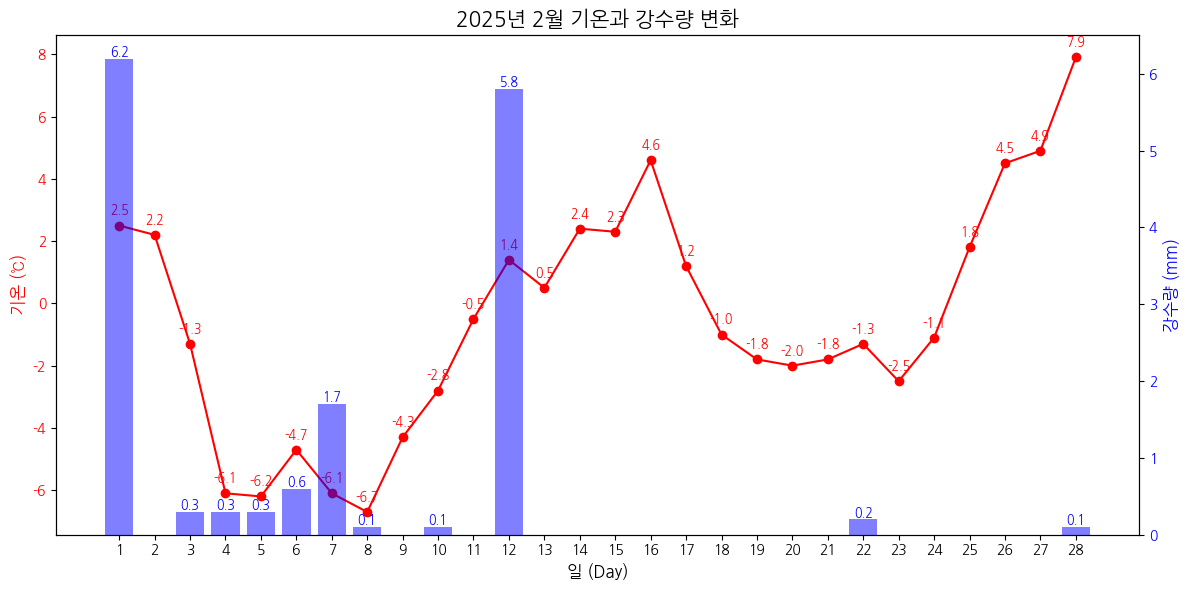

In [41]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

# 1. 2025년 2월 데이터 쏙쏙 뽑기 (이제 숫자(int)로 바뀌었으니 2025, 2 라고 씁니다!)
condition = (df['연도'] == 2025) & (df['월'] == 2)
df_2025_02 = df[condition]

# 2. 그래프 그리기 준비!
fig, ax1 = plt.subplots(figsize=(12, 6))

# 3. 주축(왼쪽)에 기온 선 그래프 그리기 (빨간색 선)
ax1.plot(df_2025_02['일'], df_2025_02['기온(℃)'], color='red', marker='o', label='기온(℃)')
ax1.set_xlabel('일 (Day)', fontsize=12)
ax1.set_ylabel('기온 (℃)', color='red', fontsize=12)
ax1.tick_params(axis='y', labelcolor='red')

# x축(날짜) 눈금을 1일씩 전부 다 표시하기!
ax1.set_xticks(df_2025_02['일'])

# 기온 선 그래프 점 위에 숫자 값 적어주기
for i, txt in enumerate(df_2025_02['기온(℃)']):
    ax1.annotate(f'{txt}', (df_2025_02['일'].iloc[i], txt), textcoords="offset points", xytext=(0,8), ha='center', color='red', fontsize=9)

# 4. 보조축(오른쪽) 만들기 (왼쪽 그래프와 같은 x축을 공유해요!)
ax2 = ax1.twinx()

# 5. 보조축(오른쪽)에 강수량 막대 그래프 그리기 (파란색 막대)
ax2.bar(df_2025_02['일'], df_2025_02['강수량(mm)'], color='blue', alpha=0.5, label='강수량(mm)')
ax2.set_ylabel('강수량 (mm)', color='blue', fontsize=12)
ax2.tick_params(axis='y', labelcolor='blue')

# 강수량 막대 그래프 위에 숫자 값 적어주기 (비가 안 온 날 0.0은 빼고 적어요!)
for i, txt in enumerate(df_2025_02['강수량(mm)']):
    if txt > 0:
        ax2.annotate(f'{txt}', (df_2025_02['일'].iloc[i], txt), textcoords="offset points", xytext=(0,2), ha='center', color='blue', fontsize=9)

# 6. 그래프 제목 달기
plt.title('2025년 2월 기온과 강수량 변화', fontsize=15)

# 7. 화면에 예쁘게 보여주기
fig.tight_layout() # 글자가 안 겹치게 정리해줘요
plt.savefig('2025년_2월_기온강수량.png')
plt.show()

# 6. 2025년 1월부터 12월까지 모든 그래프를 한 그림에 그려보기!
`plt.subplots(4, 3)` 코드를 사용하면 가로 3칸, 세로 4칸으로 나누어서 총 12개의 그래프를 한 장의 멋진 그림으로 짠! 하고 보여줄 수 있어요.

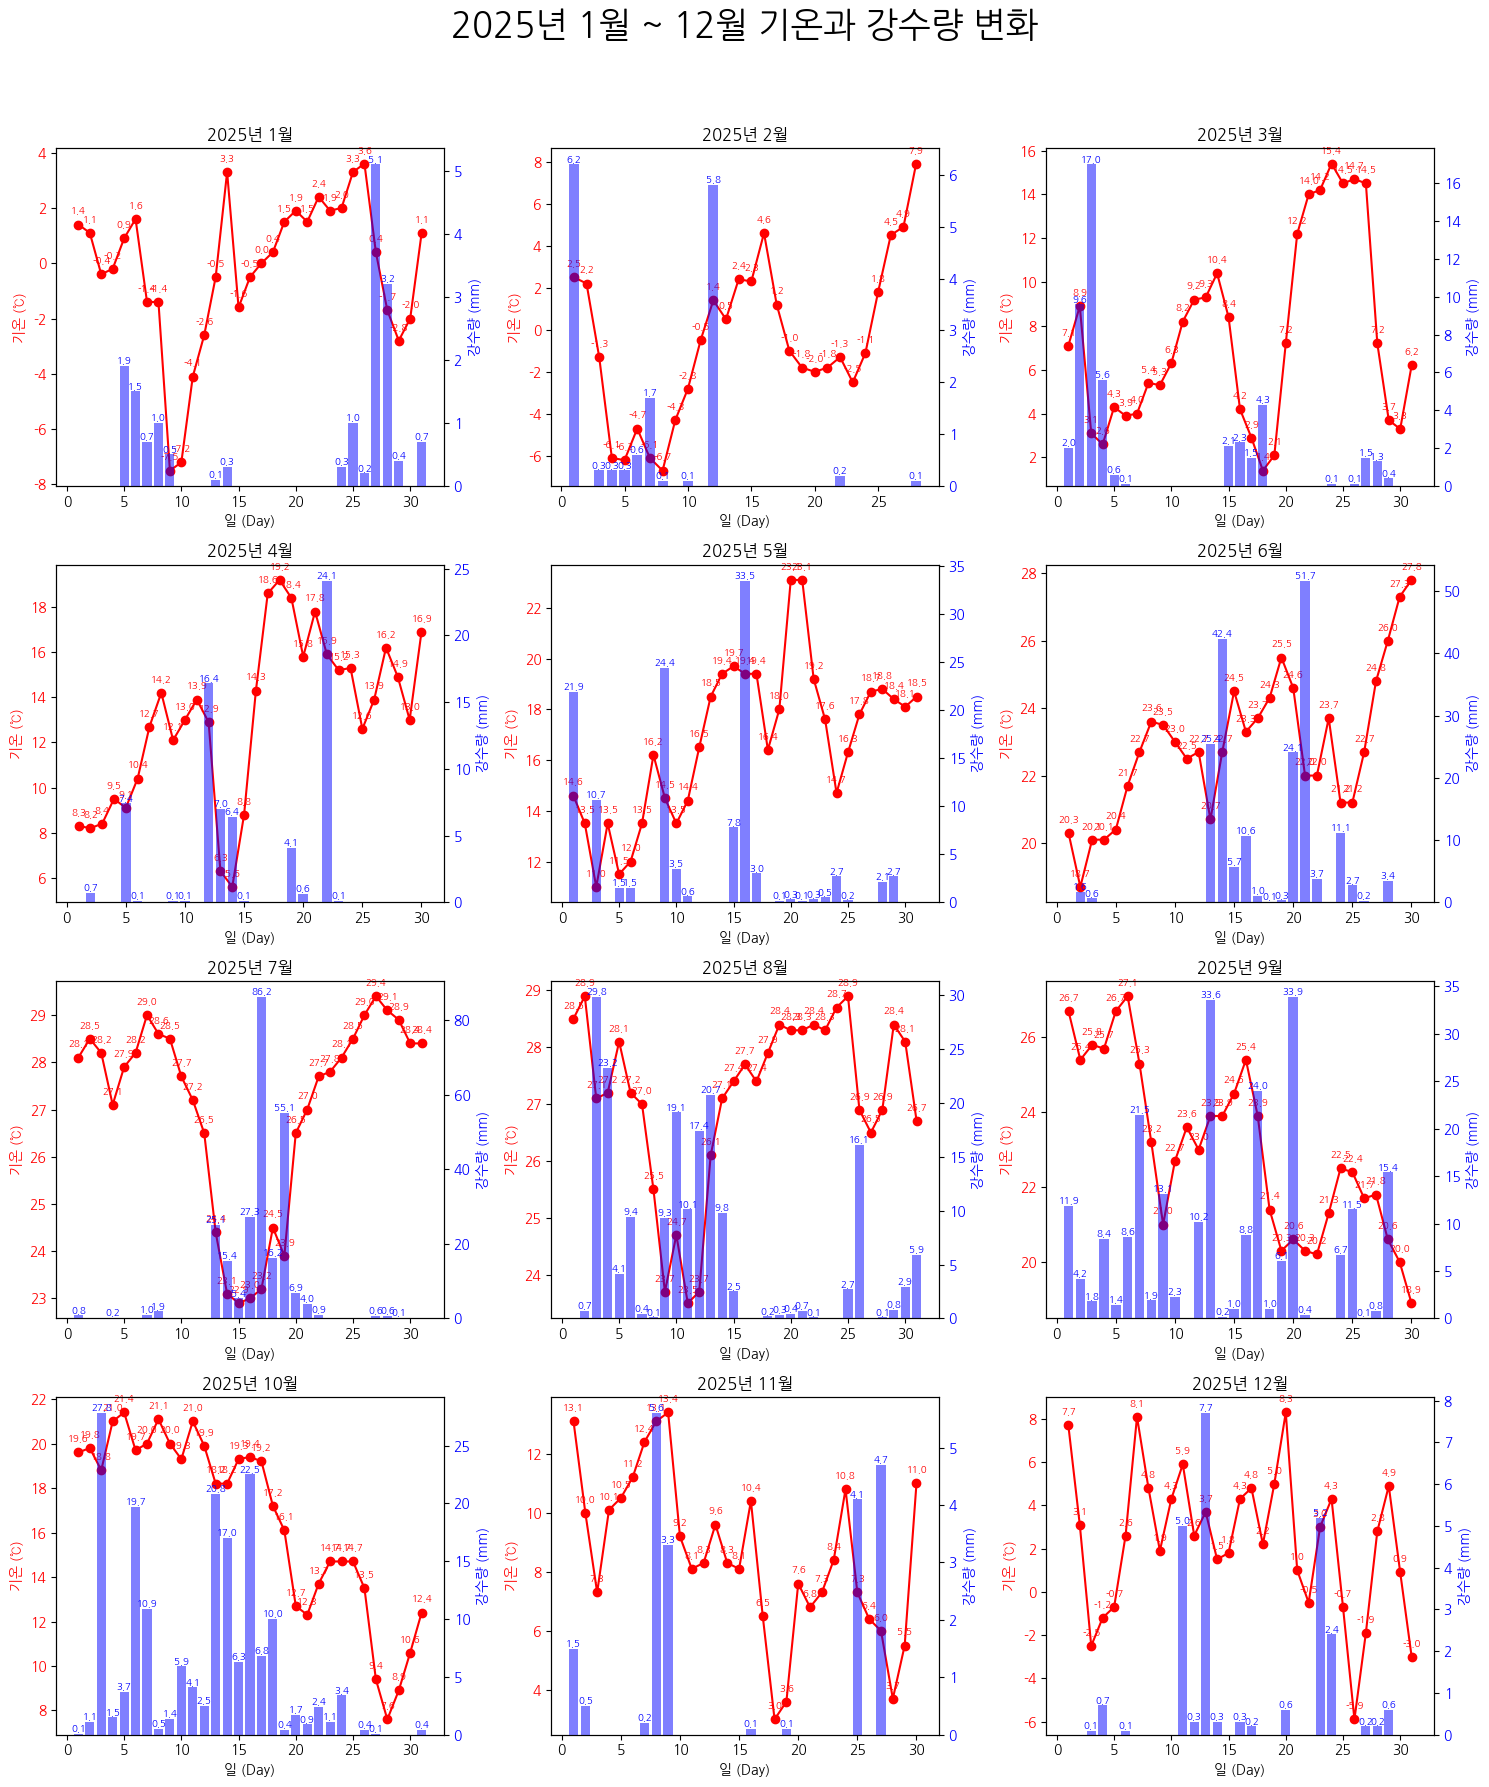

In [42]:
# 1. 12개의 그래프를 그릴 큰 도화지(4줄, 3칸) 준비하기!
fig, axes = plt.subplots(4, 3, figsize=(15, 18))
plt.subplots_adjust(hspace=0.5, wspace=0.4) # 그래프들 사이의 간격을 띄워줘요

# 1월부터 12월까지 차례대로 그려요!
for i, month in enumerate(range(1, 13)):
    # 그래프를 그릴 위치(몇 번째 줄, 몇 번째 칸)를 계산해요
    row = i // 3
    col = i % 3
    ax1 = axes[row, col]
    
    # 2. 해당 월의 데이터 쏙쏙 뽑기
    condition = (df['연도'] == 2025) & (df['월'] == month)
    df_month = df[condition]
    
    # 만약 데이터가 없으면 건너뛰어요
    if len(df_month) == 0:
        continue
        
    # 3. 주축(왼쪽)에 기온 선 그래프 그리기
    ax1.plot(df_month['일'], df_month['기온(℃)'], color='red', marker='o')
    ax1.set_xlabel('일 (Day)')
    ax1.set_ylabel('기온 (℃)', color='red')
    ax1.tick_params(axis='y', labelcolor='red')
    
    # 기온 숫자 값 적어주기 (글씨 크기를 조금 작게 7로 했어요)
    for j, txt in enumerate(df_month['기온(℃)']):
        ax1.annotate(f'{txt}', (df_month['일'].iloc[j], txt), textcoords="offset points", xytext=(0,8), ha='center', color='red', fontsize=7)
    
    # 4. 보조축(오른쪽) 만들기
    ax2 = ax1.twinx()
    
    # 5. 보조축(오른쪽)에 강수량 막대 그래프 그리기
    ax2.bar(df_month['일'], df_month['강수량(mm)'], color='blue', alpha=0.5)
    ax2.set_ylabel('강수량 (mm)', color='blue')
    ax2.tick_params(axis='y', labelcolor='blue')
    
    # 강수량 숫자 값 적어주기 (비가 안 온 날 0.0은 빼고!)
    for j, txt in enumerate(df_month['강수량(mm)']):
        if txt > 0:
            ax2.annotate(f'{txt}', (df_month['일'].iloc[j], txt), textcoords="offset points", xytext=(0,2), ha='center', color='blue', fontsize=7)
    
    # 각 작은 그래프의 제목 달기
    ax1.set_title(f'2025년 {month}월', fontsize=12)

# 6. 전체 그림의 제일 큰 제목 달기
fig.suptitle('2025년 1월 ~ 12월 기온과 강수량 변화', fontsize=25, y=0.99) # 제목이 그래프 바깥 맨 위에 있게 해요!
fig.tight_layout(rect=[0, 0, 1, 0.96]) # 큰 제목이 들어갈 공간을 확보해요

# 화면에 예쁘게 보여주기
plt.savefig('2025년_월별_기온강수량.png')
plt.show()

# 7. 매년 기온은 어떻게 변했을까? (최고, 최저, 평균기온 모두 보기)
이번에는 우리가 가진 데이터에서 **각 연도별로 가장 더웠던 온도(최고기온), 가장 추웠던 온도(최저기온), 그리고 평균 기온**을 한꺼번에 찾아서 선 그래프로 그려볼 거예요!
`groupby('연도')`라는 마법의 단어를 쓰면 연도별로 데이터를 묶어서 한 번에 여러 가지 온도를 모두 계산할 수 있답니다.

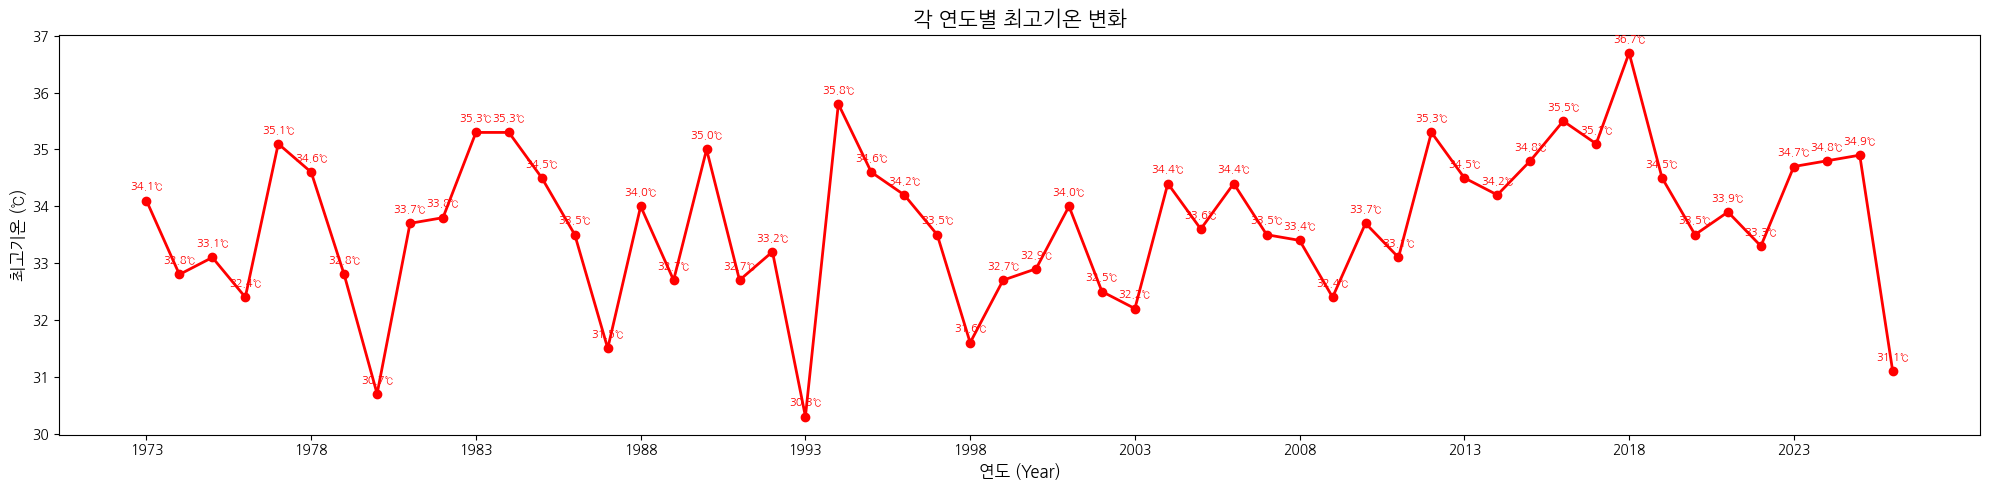

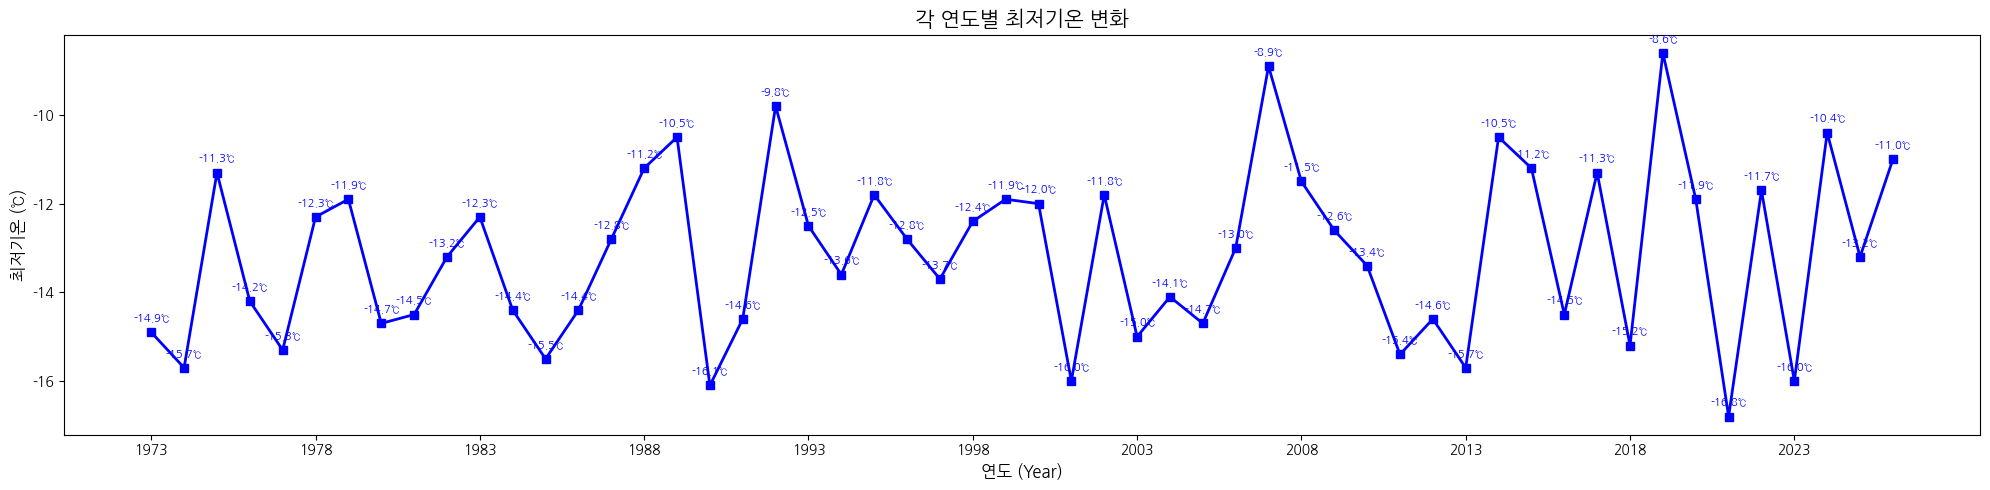

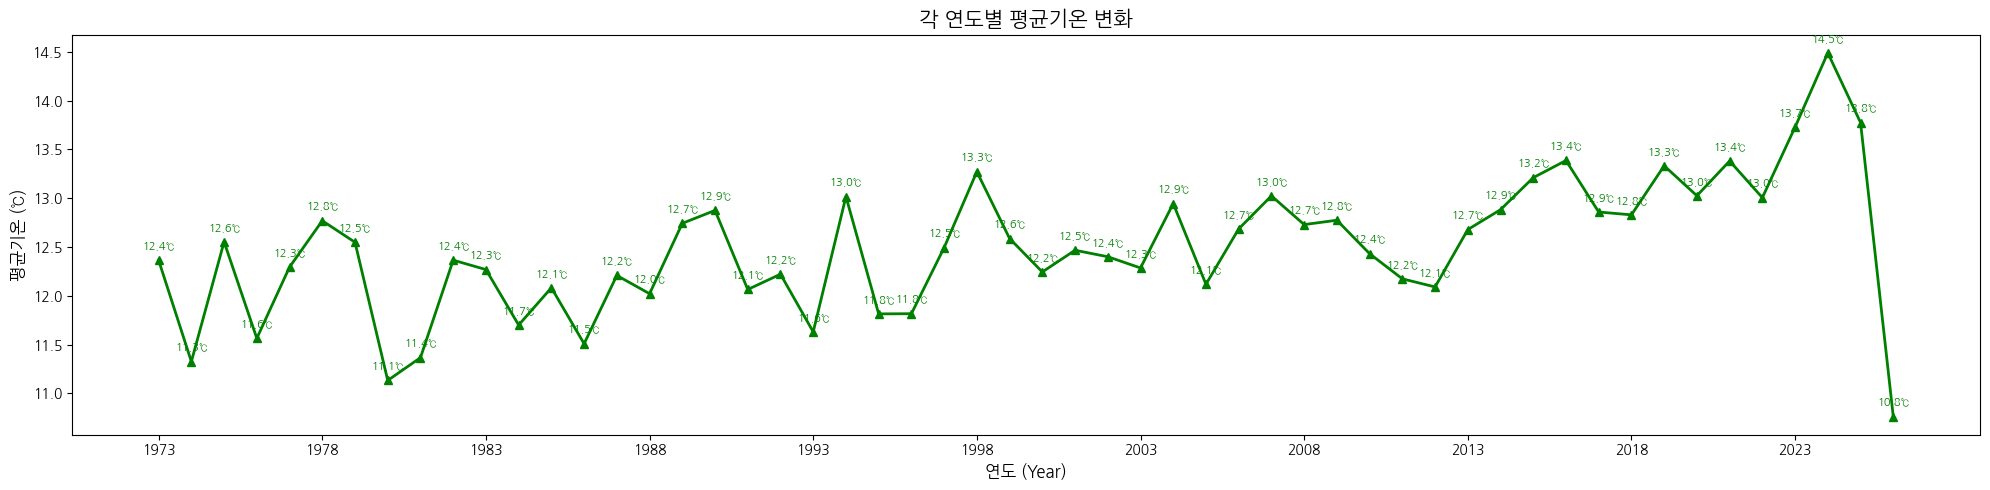

In [43]:
# 1. 각 연도별로 최고기온, 최저기온, 평균기온을 구해요!
max_temp_by_year = df.groupby('연도')['최고기온(℃)'].max()
min_temp_by_year = df.groupby('연도')['최저기온(℃)'].min()
avg_temp_by_year = df.groupby('연도')['기온(℃)'].mean()

# ==========================================
# 첫 번째 그래프: 최고기온만 따로 그리기
plt.figure(figsize=(20, 5))
plt.plot(max_temp_by_year.index, max_temp_by_year.values, color='red', marker='o', linewidth=2)
plt.title('각 연도별 최고기온 변화', fontsize=15)
plt.xlabel('연도 (Year)', fontsize=12)
plt.ylabel('최고기온 (℃)', fontsize=12)
plt.xticks(range(max_temp_by_year.index.min(), max_temp_by_year.index.max() + 1, 5))
for i, txt in enumerate(max_temp_by_year.values):
    plt.annotate(f'{txt}℃', (max_temp_by_year.index[i], txt), textcoords="offset points", xytext=(0,8), ha='center', color='red', fontsize=8)
plt.tight_layout()
plt.savefig('연도별_최고기온.png')
plt.show()

# ==========================================
# 두 번째 그래프: 최저기온만 따로 그리기
plt.figure(figsize=(20, 5))
plt.plot(min_temp_by_year.index, min_temp_by_year.values, color='blue', marker='s', linewidth=2)
plt.title('각 연도별 최저기온 변화', fontsize=15)
plt.xlabel('연도 (Year)', fontsize=12)
plt.ylabel('최저기온 (℃)', fontsize=12)
plt.xticks(range(min_temp_by_year.index.min(), min_temp_by_year.index.max() + 1, 5))
for i, txt in enumerate(min_temp_by_year.values):
    plt.annotate(f'{txt}℃', (min_temp_by_year.index[i], txt), textcoords="offset points", xytext=(0,8), ha='center', color='blue', fontsize=8)
plt.tight_layout()
plt.savefig('연도별_최저기온.png')
plt.show()

# ==========================================
# 세 번째 그래프: 평균기온만 따로 그리기
plt.figure(figsize=(20, 5))
plt.plot(avg_temp_by_year.index, avg_temp_by_year.values, color='green', marker='^', linewidth=2)
plt.title('각 연도별 평균기온 변화', fontsize=15)
plt.xlabel('연도 (Year)', fontsize=12)
plt.ylabel('평균기온 (℃)', fontsize=12)
plt.xticks(range(avg_temp_by_year.index.min(), avg_temp_by_year.index.max() + 1, 5))
for i, txt in enumerate(avg_temp_by_year.values):
    plt.annotate(f'{txt:.1f}℃', (avg_temp_by_year.index[i], txt), textcoords="offset points", xytext=(0,8), ha='center', color='green', fontsize=8)
plt.tight_layout()
plt.savefig('연도별_평균기온.png')
plt.show()


# 8. 매년 내린 비의 양(총 강수량) 알아보기
기온뿐만 아니라, **각 연도별로 비가 총 얼마나 내렸는지**도 살펴볼까요?
`groupby('연도')`로 묶은 다음 이번에는 제일 큰 값을 찾는 `max()`가 아니라 전부 다 더하는 `sum()`을 쓰면 1년 치 비의 양을 알 수 있어요!

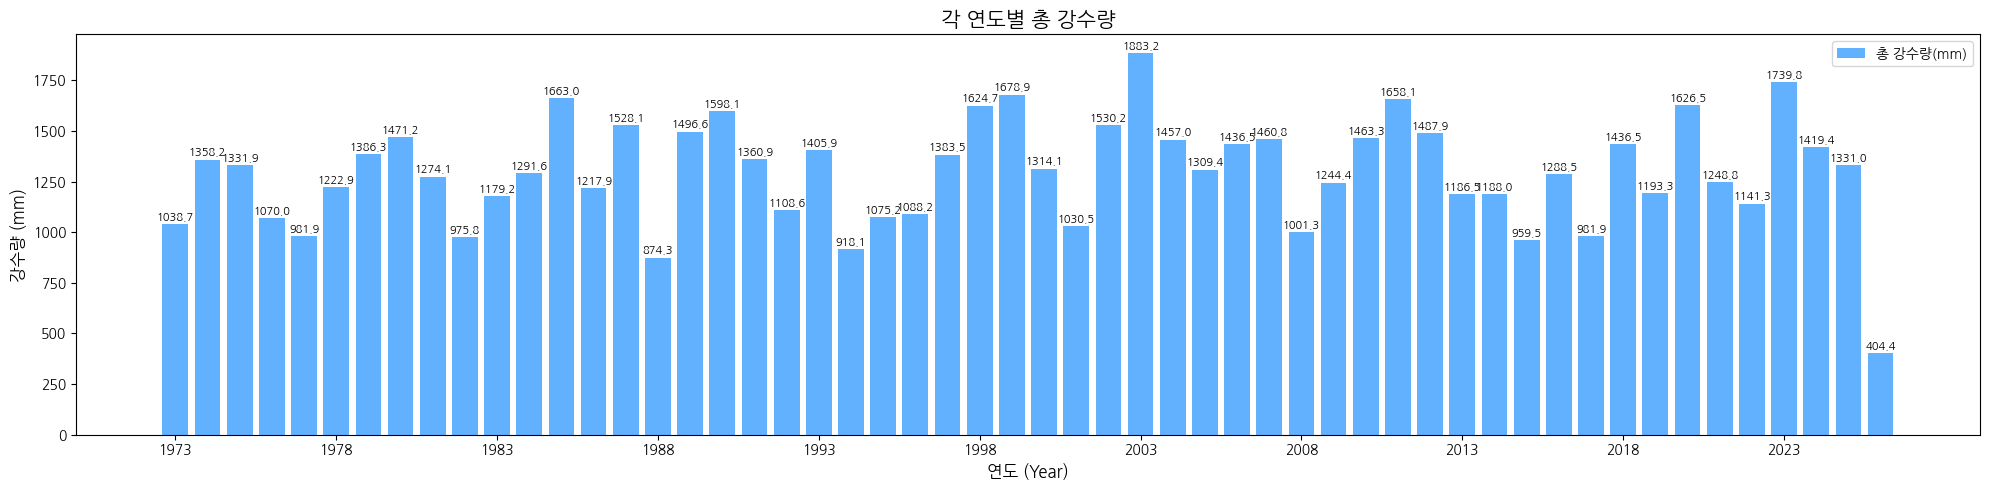

In [44]:
# 1. 각 연도별로 '강수량(mm)'을 모두 더해서(sum) 총 강수량을 구해요!
total_rain_by_year = df.groupby('연도')['강수량(mm)'].sum()

# 2. 그래프 그리기 준비!
plt.figure(figsize=(20, 5))

# 3. 막대 그래프 그리기 (파란색 막대)
plt.bar(total_rain_by_year.index, total_rain_by_year.values, color='dodgerblue', alpha=0.7, label='총 강수량(mm)')

# 4. 그래프 제목과 축 이름 달기
plt.title('각 연도별 총 강수량', fontsize=15)
plt.xlabel('연도 (Year)', fontsize=12)
plt.ylabel('강수량 (mm)', fontsize=12)

# 연도가 5년 간격으로 표시되도록 눈금 설정하기
plt.xticks(range(total_rain_by_year.index.min(), total_rain_by_year.index.max() + 1, 5))

# 5. 막대 위에 강수량 숫자 값 적어주기 (소수점 첫째 자리까지만 보이게)
for i, txt in enumerate(total_rain_by_year.values):
    plt.annotate(f'{txt:.1f}', (total_rain_by_year.index[i], txt), textcoords="offset points", xytext=(0,3), ha='center', color='black', fontsize=8)

# 화면에 예쁘게 보여주기
plt.legend()
plt.tight_layout()
plt.savefig('연도별_총강수량.png')
plt.show()


# 9. 비가 많이 오면 기온도 높을까? (점 그래프 그려보기)
<b>산포도(점 그래프)</b>는 두 가지 값이 서로 어떤 짝꿍 관계인지 알아볼 때 쓰는 재미있는 그래프예요!
가로 방향에는 '비가 온 양(강수량)'을, 세로 방향에는 '그날의 기온'을 두고, 두 값이 만나는 곳에 점을 콕콕 찍어보는 거예요.
점들이 흩어져 있는 모양을 보면 비가 많이 올 때 보통 날씨가 더운지, 추운지 한눈에 알 수 있답니다!

이번에는 1개의 커다란 도화지에 3개의 그래프를 나란히 그려볼 거예요.
- 첫 번째: 강수량과 기온
- 두 번째: 강수량과 최고기온
- 세 번째: 강수량과 최저기온

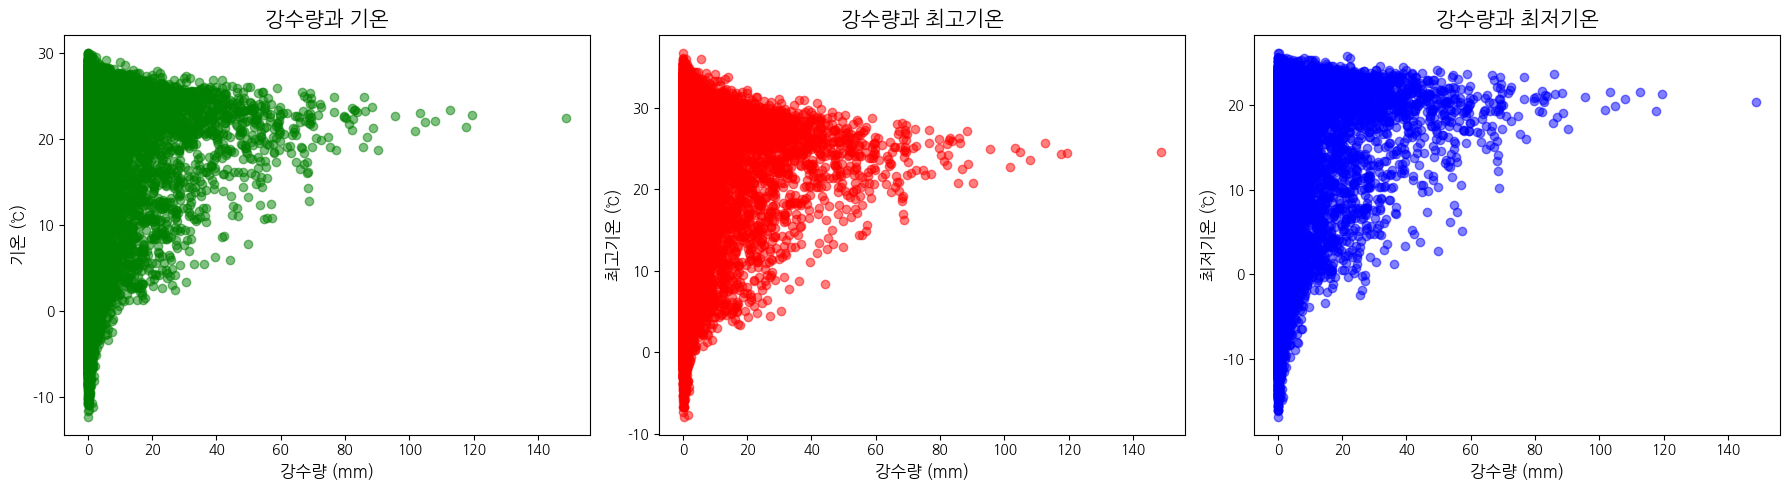

In [45]:
# 1. 1줄에 3칸짜리 도화지를 준비해요
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 2. 첫 번째 그래프: 강수량과 기온
axes[0].scatter(df['강수량(mm)'], df['기온(℃)'], color='green', alpha=0.5)
axes[0].set_title('강수량과 기온', fontsize=15)
axes[0].set_xlabel('강수량 (mm)', fontsize=12)
axes[0].set_ylabel('기온 (℃)', fontsize=12)

# 3. 두 번째 그래프: 강수량과 최고기온
axes[1].scatter(df['강수량(mm)'], df['최고기온(℃)'], color='red', alpha=0.5)
axes[1].set_title('강수량과 최고기온', fontsize=15)
axes[1].set_xlabel('강수량 (mm)', fontsize=12)
axes[1].set_ylabel('최고기온 (℃)', fontsize=12)

# 4. 세 번째 그래프: 강수량과 최저기온
axes[2].scatter(df['강수량(mm)'], df['최저기온(℃)'], color='blue', alpha=0.5)
axes[2].set_title('강수량과 최저기온', fontsize=15)
axes[2].set_xlabel('강수량 (mm)', fontsize=12)
axes[2].set_ylabel('최저기온 (℃)', fontsize=12)

# 5. 화면에 예쁘게 보여주기
fig.tight_layout() # 그래프끼리 안 겹치게 해줘요
plt.savefig('기후산포도_3종.png')
plt.show()
